## Umbralizacion binaria y binaria inversa

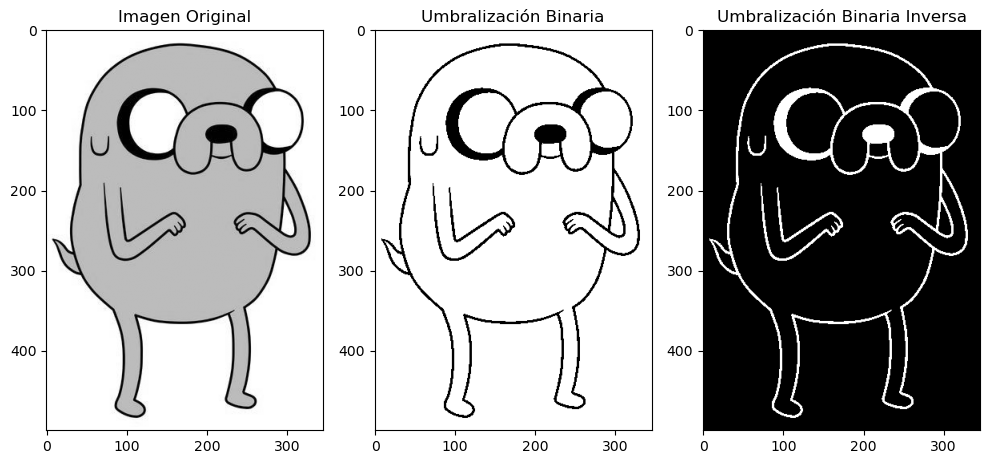

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('jake.jpg',0)#lee en escala de grises

#umbralizacion binaria
_,umbral_binaria=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)#se puede bajar los numeros y cambia la imagen 

#umbralizacion binaria inversa
_,umbral_binaria_inversa=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,3,2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binaria,cmap='gray')
plt.subplot(1,3,3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binaria_inversa,cmap='gray')
plt.tight_layout()
plt.show()

## Transformacion de YUV2RGB a RGBYUV y viceversa

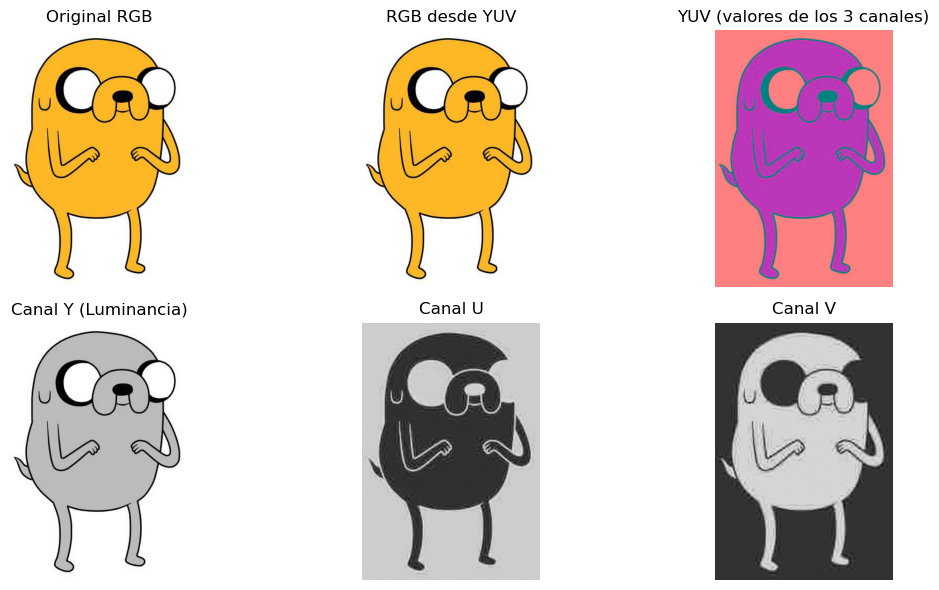

In [ ]:

import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('jake.jpg')
if imagen_bgr is None:
    raise FileNotFoundError('jake.jpg no encontrada en el directorio actual.')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

yuv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YUV)

rgb_from_yuv = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

Y, U, V = cv2.split(yuv)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(imagen_rgb); plt.title('Original RGB'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(rgb_from_yuv); plt.title('RGB desde YUV'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(yuv); plt.title('YUV (valores de los 3 canales)'); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(Y, cmap='gray'); plt.title('Canal Y (Luminancia)'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(U, cmap='gray'); plt.title('Canal U'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(V, cmap='gray'); plt.title('Canal V'); plt.axis('off')
plt.tight_layout()
plt.show()

## Ejemplos de filtro Bayer 

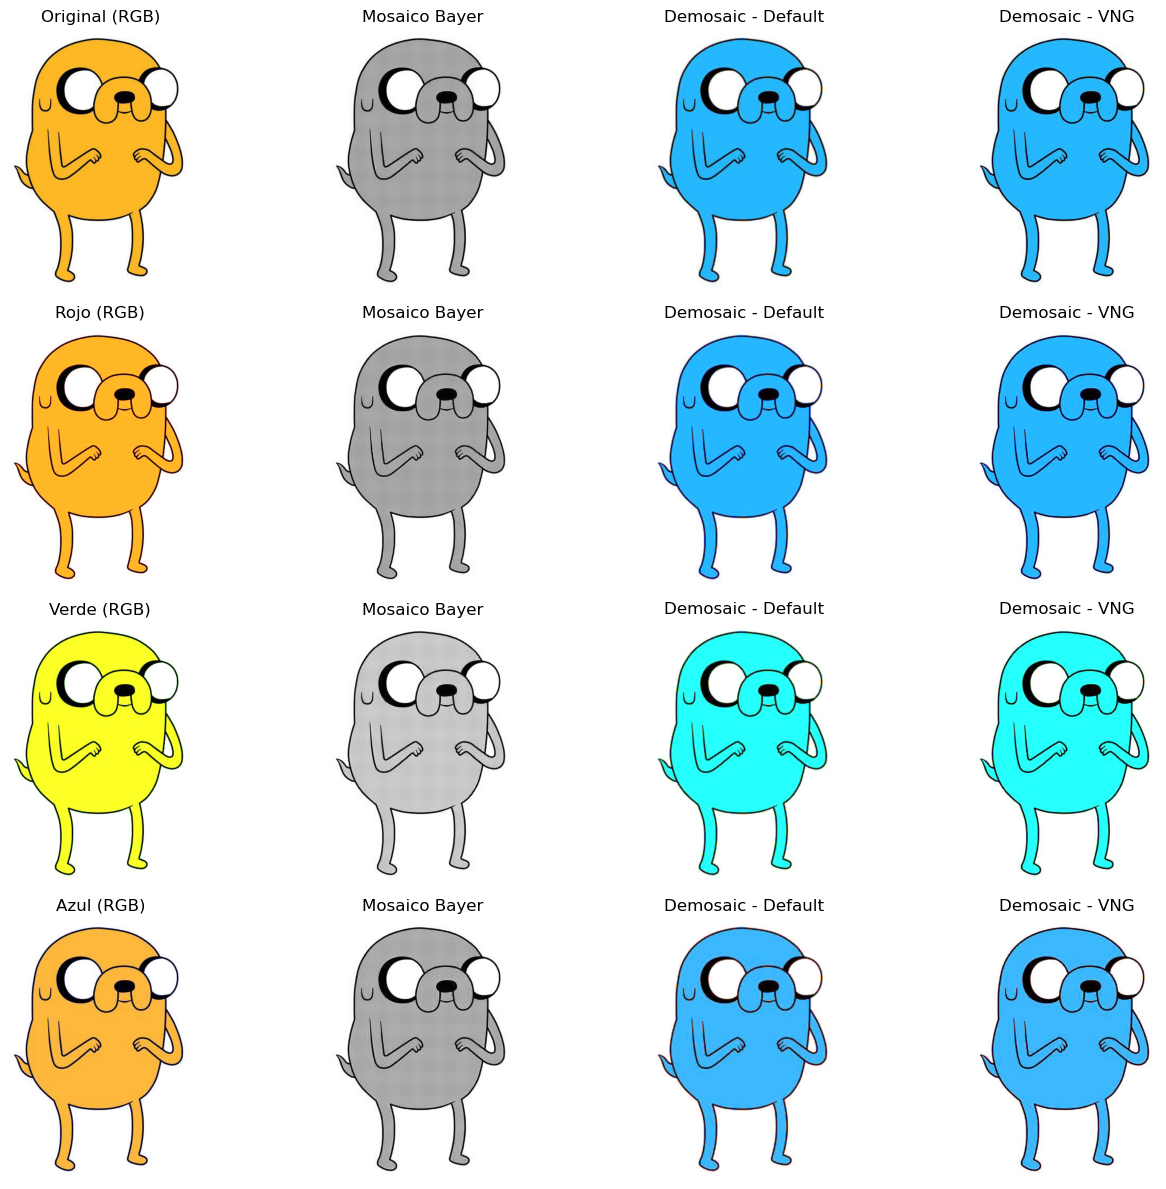

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('jake.jpg')
if img_bgr is None:
    raise FileNotFoundError('jake.jpg no encontrada en el directorio actual.')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_to_bayer(rgb):
    h,w,_ = rgb.shape
    bayer = np.zeros((h,w), dtype=rgb.dtype)
    bayer[0::2,0::2] = rgb[0::2,0::2,2]  # B
    bayer[0::2,1::2] = rgb[0::2,1::2,1]  # G
    bayer[1::2,0::2] = rgb[1::2,0::2,1]  # G
    bayer[1::2,1::2] = rgb[1::2,1::2,0]  # R
    return bayer

def boost_channel(rgb, channel, factor):
    out = rgb.astype(np.float32).copy()
    out[..., channel] = np.clip(out[..., channel] * factor, 0, 255)
    return out.astype(np.uint8)

orig = img_rgb
red = boost_channel(img_rgb, 0, 1.6)
green = boost_channel(img_rgb, 1, 1.6)
blue = boost_channel(img_rgb, 2, 1.6)

variants = [('Original', orig), ('Rojo', red), ('Verde', green), ('Azul', blue)]

results = []
for name, var in variants:
    bayer = rgb_to_bayer(var)
    dem_default = cv2.cvtColor(bayer, cv2.COLOR_BAYER_BG2BGR)
    dem_vng = cv2.cvtColor(bayer, cv2.COLOR_BAYER_BG2BGR_VNG)
    dem_default = cv2.cvtColor(dem_default, cv2.COLOR_BGR2RGB)
    dem_vng = cv2.cvtColor(dem_vng, cv2.COLOR_BGR2RGB)
    results.append((name, var, bayer, dem_default, dem_vng))

rows = len(results)
fig, axes = plt.subplots(rows, 4, figsize=(14, 3*rows))
for i, (name, var, bayer, dem_def, dem_vng) in enumerate(results):
    axes[i,0].imshow(var); axes[i,0].set_title(f'{name} (RGB)'); axes[i,0].axis('off')
    axes[i,1].imshow(bayer, cmap='gray'); axes[i,1].set_title('Mosaico Bayer'); axes[i,1].axis('off')
    axes[i,2].imshow(dem_def); axes[i,2].set_title('Demosaic - Default'); axes[i,2].axis('off')
    axes[i,3].imshow(dem_vng); axes[i,3].set_title('Demosaic - VNG'); axes[i,3].axis('off')

plt.tight_layout()
plt.show()

## UMBRALIZACION PARTE 2 (UMBRALIZACION GLOBAL UMBRALIZACION ISODATA)

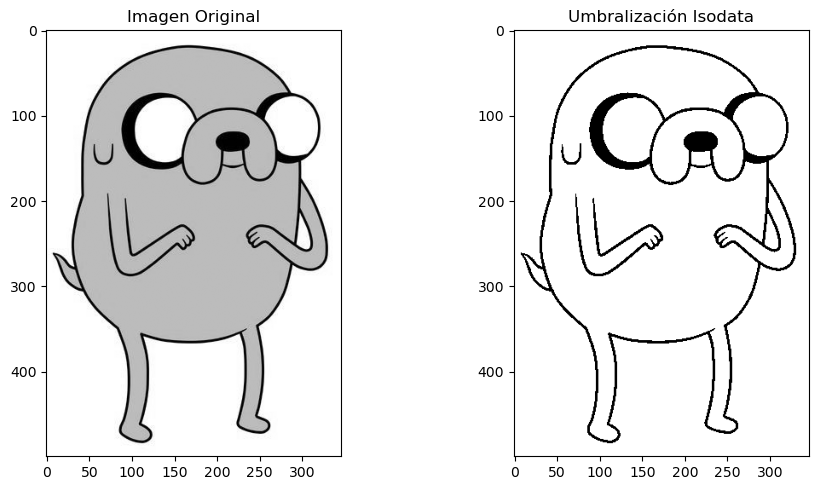

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata (image):
    #decidimos umbral incial de 0 a 25
    umbral=128 #puedo cambiar cuando se requiera
    while True:
        grupo1=image[image<=umbral]#grupo donde el umbral es menor o igual al umbral
        grupo2=image[image>umbral]#grupo donde el umbral es mayor al umbral
        #calculo la media de cada grupo
        media1=np.mean(grupo1)
        media2=np.mean(grupo2)
        #calculamos el nuevo valor del umbral
        nuevo_umbral=(media1+media2)/2
        #si el nuevo umbral es igual al anterior, salimos del ciclo
        if nuevo_umbral==umbral:
            break
        umbral=nuevo_umbral
    return umbral
imagen=cv2.imread('jake.jpg',0)
umbral_isodata=isodata(imagen)
_,umbralizacion_isodata=cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Isodata')
plt.imshow(umbralizacion_isodata,cmap='gray')
plt.tight_layout()
plt.show()


## UMBRALIZACION DE DOS PICOS

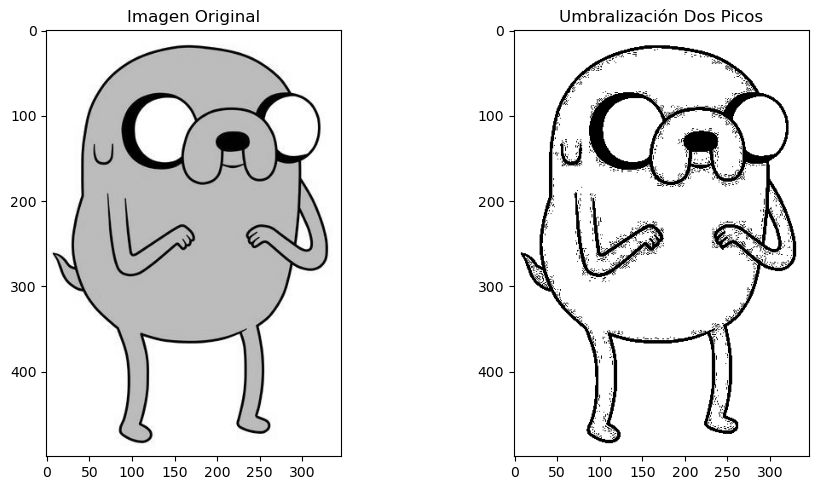

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    #calculo de histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()#calcula el histograma de la imagen y lo aplana a un array unidimensional
    #seleccionamos los dos picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)#diferencia entre picos
    primer_pico=np.argmax(pico_dif[:128])#pico hasta 127
    segundo_pico=np.argmax(pico_dif[128:])+128#pico desde 128 para adelante
    #calculo umbral
    umbral=int((primer_pico+segundo_pico)/2)
    return umbral
imagen=cv2.imread('jake.jpg',0)
umbral_dos_picos=dos_picos(imagen)
_,nueva=cv2.threshold(imagen,umbral_dos_picos,255,cv2.THRESH_BINARY)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Dos Picos')
plt.imshow(nueva,cmap='gray')
plt.tight_layout()
plt.show()

## UMBRALIZACION OTSU

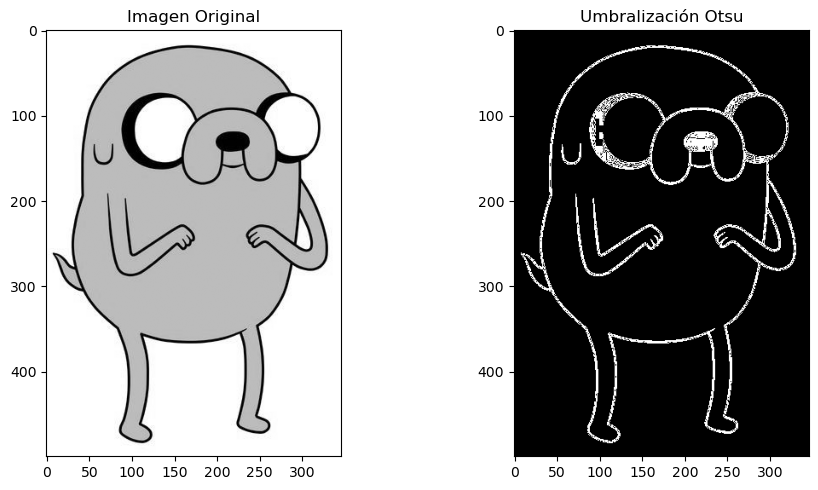

In [6]:
import cv2
from matplotlib import image
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('jake.jpg',0)#escala de grises
_,otsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)#se puede combinar entre diferentes tipos de umbralizacion
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Otsu')
plt.imshow(imagen_fin,cmap='gray')
plt.tight_layout()
plt.show()



## UMBRALIZACION VARIABLE PARTICIPON DE UNA IMAGEN

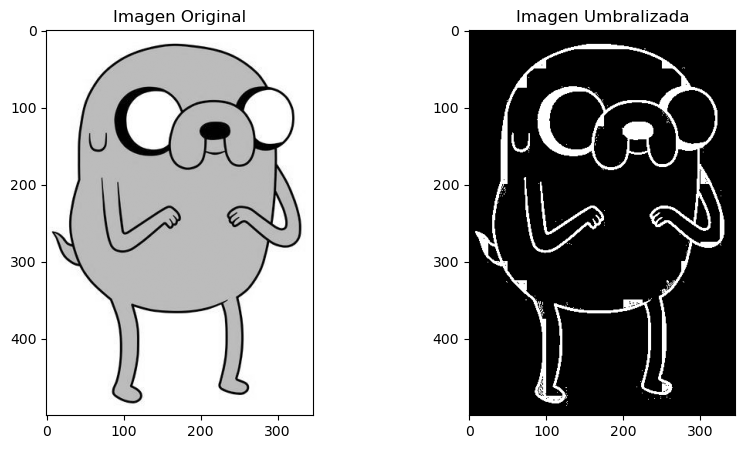

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range (0, image.shape[0], tam_bloque):#recoremos filas
        for x in range(0, image.shape[1], tam_bloque):#recoremos columnas
            bloque = image[y:y+tam_bloque, x:x+tam_bloque]#vemos el bloque de la imagen
            bloq_media=np.mean(bloque)#calculo la media del bloque
            umbral=bloq_media-c#calculo el umbral sumando la media del bloque con una constante
            umbral_img[y:y+tam_bloque, x:x+tam_bloque]=(bloque>umbral)+255

    return umbral_img
tam_b=25
c=10
imagen=cv2.imread('jake.jpg',0)
img_fin=variable_part(imagen,tam_b,c)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada')
plt.imshow(img_fin,cmap='gray')


## PROPIEDADES LOCALES

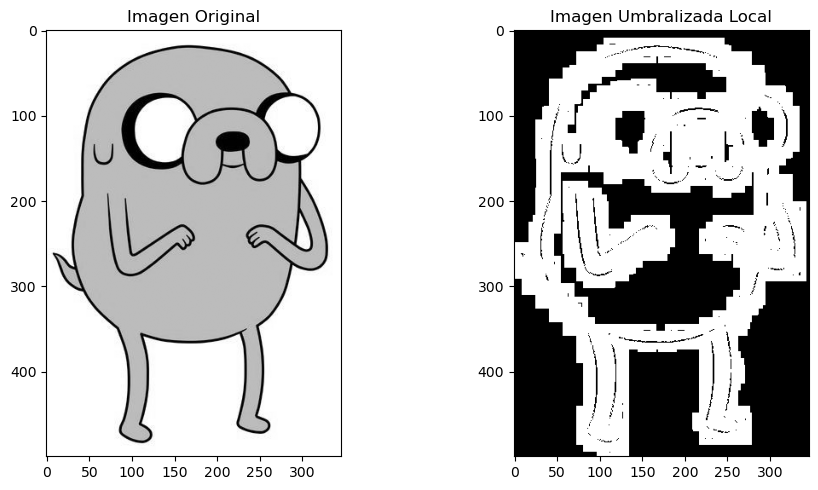

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('jake.jpg',0)#escala de grises
def local (iamge,tamanio_ventana,k):
    umbr_img=np.zeros_like(image)
    #definir un rastreo de imagen padding
    pad=tamanio_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y+tamanio_ventana,x:x+tamanio_ventana]#ventana de la imagen
            mean_local=np.mean(ventana)#calculo la media de la ventana
            std_mean=np.std(ventana)#calculo la desviacion estandar de la ventana
            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tam_vent=15
k=2
img_fin=local(image,tam_vent,k)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(image,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada Local')
plt.imshow(img_fin,cmap='gray')
plt.tight_layout()
plt.show()

## VARIABLE CON OPEN VC

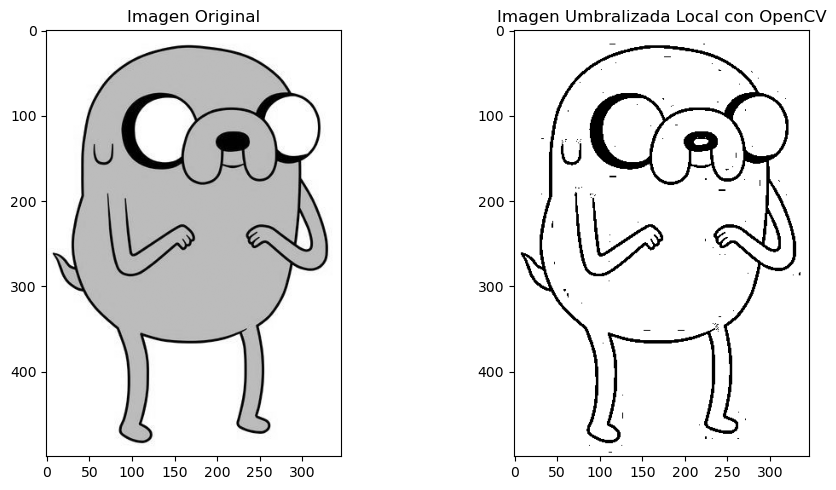

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('jake.jpg',0)

ventana=15
k=2
imagen_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(image,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada Local con OpenCV')
plt.imshow(imagen_fin,cmap='gray')
plt.tight_layout()
plt.show()

## FORMULA OTSU


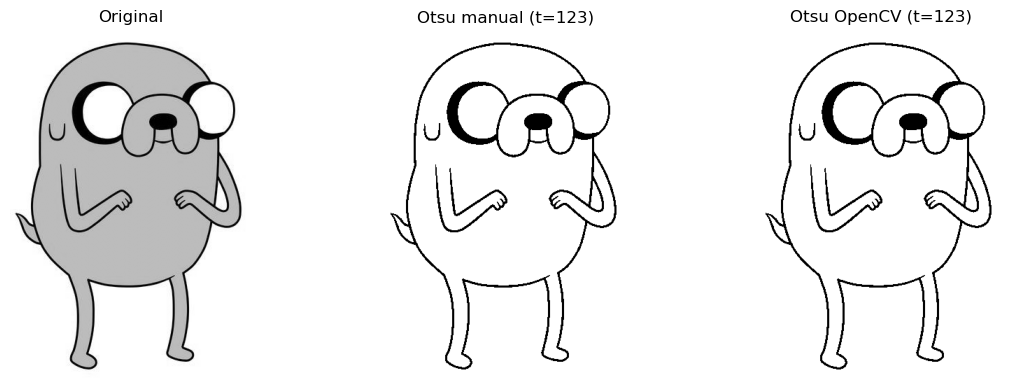

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def otsu_manual(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    total = image.size
    sum_total = np.dot(np.arange(256), hist)
    w0 = 0.0
    sumB = 0.0
    max_between = 0.0
    threshold = 0
    for t in range(256):
        w0 += hist[t]
        if w0 == 0:
            continue
        w1 = total - w0
        if w1 == 0:
            break
        sumB += t * hist[t]
        mu0 = sumB / w0
        mu1 = (sum_total - sumB) / w1
        # aplicamos la fórmula
        between = (w0/total) * (w1/total) * (mu0 - mu1) ** 2
        if between > max_between:
            max_between = between
            threshold = t
    return threshold, max_between

imagen = cv2.imread('jake.jpg', 0)

t_manual, val = otsu_manual(imagen)
t_cv, bin_cv = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, bin_manual = cv2.threshold(imagen, t_manual, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(imagen, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(bin_manual, cmap='gray'); plt.title(f'Otsu manual (t={t_manual})'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(bin_cv, cmap='gray'); plt.title(f'Otsu OpenCV (t={int(t_cv)})'); plt.axis('off')
plt.tight_layout()
plt.show()